# Task 4 

Using smarties.png which has objects in a few different colours. I went with red because
there are several red ones in the image (no yellow ones at all, I checked).

Converting to HSV first because in BGR the brightness is mixed into all three channels,
so a bright red and a dark red have totally different values. HSV splits colour (H) away
from brightness (V), so I can grab "all red regardless of lighting" with one hue range.

In OpenCV H goes 0-179 (not 360), S and V go 0-255.

Two masks as required:
1. Restrictive: H 0-5, S 200-255, V 200-255
2. Better one: H 0-10, S 100-255, V 80-255

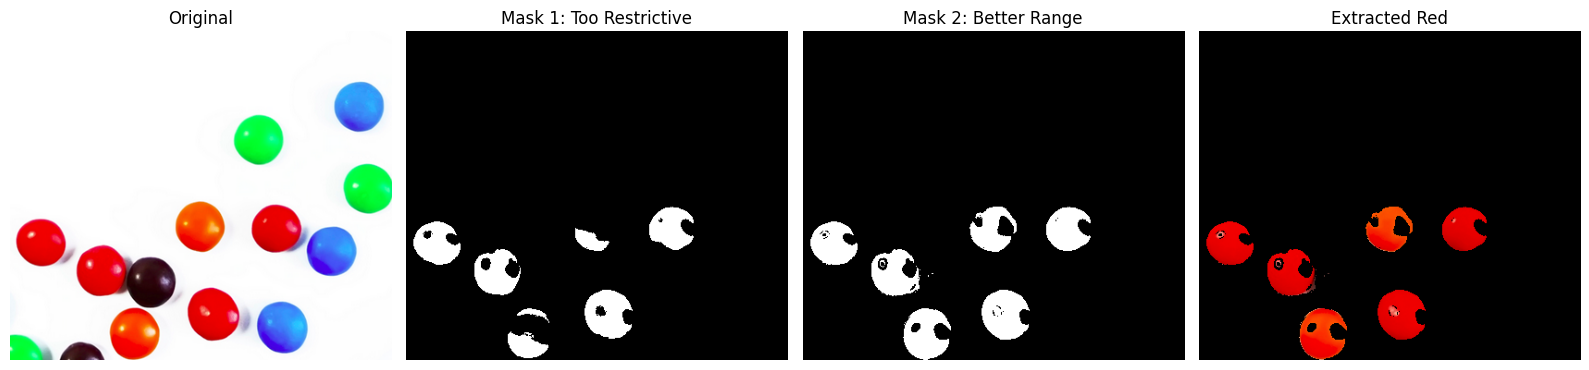

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("smarties.png")

if img is None:
    print("Error: smarties.png not found")
else:
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask 1: too restrictive, only perfect bright red
    tight_low  = np.array([0, 200, 200])
    tight_high = np.array([5, 255, 255])
    mask_tight = cv2.inRange(hsv, tight_low, tight_high)

    # Mask 2: wider range, catches shadows and highlights too
    wide_low  = np.array([0, 100, 80])
    wide_high = np.array([10, 255, 255])
    mask_wide = cv2.inRange(hsv, wide_low, wide_high)

    # Pull the red out of the original using the good mask
    extracted = cv2.bitwise_and(img, img, mask=mask_wide)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(mask_tight, cmap="gray")
    plt.title("Mask 1: Too Restrictive")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(mask_wide, cmap="gray")
    plt.title("Mask 2: Better Range")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(cv2.cvtColor(extracted, cv2.COLOR_BGR2RGB))
    plt.title("Extracted Red")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### Results

Mask 1 comes out broken ; the orange one in the middle is only a crescent, one of the
red ones at the bottom is just a sliver, and most of them are missing chunks.

Mask 2 catches all six red/orange ones as full solid circles.

**Why does the restrictive mask fail?**

Because a real object isn't one flat colour. The top of each smartie catches the light
and washes out towards white, which means the saturation drops. The curved edge goes into
shadow, which means the value drops. The tight mask demands S and V both above 200, so it
only accepts the small perfectly-lit band in the middle of each one and rejects everything
else.

Dropping the lower bounds to S=100 and V=80 lets the shadowed and highlighted parts of
the same object pass, so the masks fill in properly.

**One thing I noticed**

Both masks have little bite-shaped gaps where the white highlight sits on each smartie.
Those spots are nearly pure white, so saturation is almost zero and they fall outside any
hue range no matter how wide I make it. Neither mask catches them.